## Configure environment

In [ ]:
import random
import time
import os
import datetime
import itertools
import math
import sys
from random import randint
import shutil

In [ ]:
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

In [ ]:
if IN_COLAB:
  COLAB_BASE_DIR = "/content/gdrive/MyDrive/Universidad/VIU/TFM/notebooks/"
  from google.colab import drive
  drive.mount('/content/gdrive/')
  sys.path.append(os.path.join(COLAB_BASE_DIR, 'ConvLSTM'))
  sys.path.append(os.path.join(COLAB_BASE_DIR, 'common'))

Mounted at /content/gdrive/


In [ ]:
if IN_COLAB:
  if not os.path.exists("/data/masked_clouds.hdf5"):
    %mkdir -p /data
    shutil.copyfile(os.path.join(COLAB_BASE_DIR, "common/masked_clouds.hdf5"), "/data/masked_clouds.hdf5")

In [ ]:
%%capture
%pip install torch torchvision h5py xarray matplotlib

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.v2 as v2
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.utils.data as data
from torch.utils.data import DataLoader, random_split
import numpy as np
import h5py
import PIL.Image
from IPython.core import display as idisplay
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr

import ConvLSTMmodels
if not IN_COLAB:
  sys.path.append('../common')
import common

In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
if not IN_COLAB:
  common.set_memory_limit_if_not_limit(1.5)

In [ ]:
os.makedirs('save', exist_ok=True)

## Load data

In [ ]:
cwd = os.getcwd()
pardir = os.path.dirname(os.path.dirname(cwd))
data_folder = os.path.join(pardir,'data')
data_path = os.path.join(data_folder, 'masked_clouds.hdf5')
model_name = 'MaskedConvLSTM_Weighted'
output_path = os.path.join(cwd, "save", f"{model_name}.torch")
if IN_COLAB:
  output_path = os.path.join(COLAB_BASE_DIR, "ConvLSTM", f"{model_name}.torch")
with h5py.File(data_path, 'r') as fds:
    group_names = list(fds.keys())
    print(group_names)
    fds.close()


dss = {}
for gname in group_names:
    dss[gname] = xr.open_dataset(data_path, engine='h5netcdf', group=gname, phony_dims='sort')

['test', 'trainval']


In [ ]:
print(dss['test']['images_log'])
print(dss['test']['images_log'].shape)

<xarray.DataArray 'images_log' (phony_dim_0: 4467, phony_dim_1: 16,
                                phony_dim_2: 64, phony_dim_3: 8, phony_dim_4: 5)> Size: 183MB
[182968320 values with dtype=uint8]
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3, phony_dim_4
(4467, 16, 64, 8, 5)


# Processing data

## Dataloaders

In [ ]:
bs = 24 # batch size
transform = transforms.Compose([
    transforms.Lambda(lambda x: np.unpackbits(x, axis=1)),
    torch.from_numpy,
    transforms.Lambda(lambda x: torch.permute(x, (2, 0, 1)).float()),
])
# Create Dataset and DataLoader
full_train_dataset = common.VideoDataset(dss['trainval']['images_log'], dss['trainval']['images_pred'], transform=transform, stack_videos=False, device=device)
val_ratio = 0.1
n_val = int(len(full_train_dataset) * val_ratio)
n_train = len(full_train_dataset) - n_val
train_dataset, val_dataset = random_split(full_train_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)

test_dataset = common.VideoDataset(dss['test']['images_log'], dss['test']['images_pred'], transform=transform, stack_videos=False, device=device)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Number of videos: {len(full_train_dataset.videos)}.")
print(f"Number of train videos: {len(train_dataset)}.")
print(f"Number of train video batches: {len(train_loader)}")
print(f"Number of val videos: {len(val_dataset)}.")
print(f"Number of val video batches: {len(val_loader)}")
print(f"Size of video batches: {bs}.")


Number of videos: 53336.
Number of train videos: 48003.
Number of train video batches: 2001
Number of val videos: 5333.
Number of val video batches: 223
Size of video batches: 24.


## Printer

In [ ]:
cmap = mcolors.ListedColormap(['black', 'cyan', 'yellow', 'white', 'blue'], 'CloudSegmenter')

torch.Size([5, 64, 64])
torch.Size([64, 64])
[0 1 3 4]


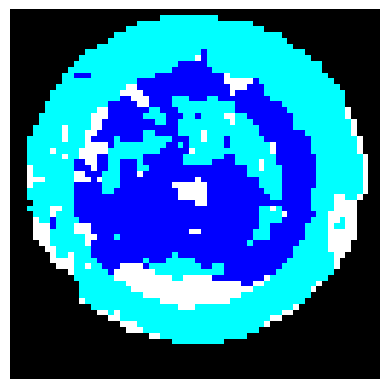

In [ ]:
testim = next(iter(train_loader))[0][1][0]
print(testim.shape)
testim = torch.argmax(testim, dim=0).cpu()
print(testim.shape)
print(np.unique(testim))
plt.axis('off')
plt.imshow(testim, cmap=cmap, vmin=0, vmax=5)
plt.show()

In [ ]:
def show(img):
    labels_again = torch.argmax(img, dim=1).cpu()
    f = plt.figure(figsize=(12, 12), layout='tight')
    ncols = len(img)//4 if len(img) % 4 == 0 else len(img)//4 + 1
    axarr = f.subplots(4,4)
    for i in range(len(img)):
        axarr[i//4][i%4].set_axis_off()
        axarr[i//4][i%4].imshow(labels_again[i], cmap=cmap, vmin=0, vmax=5)
    plt.show()

0
torch.Size([24, 16, 5, 64, 64])


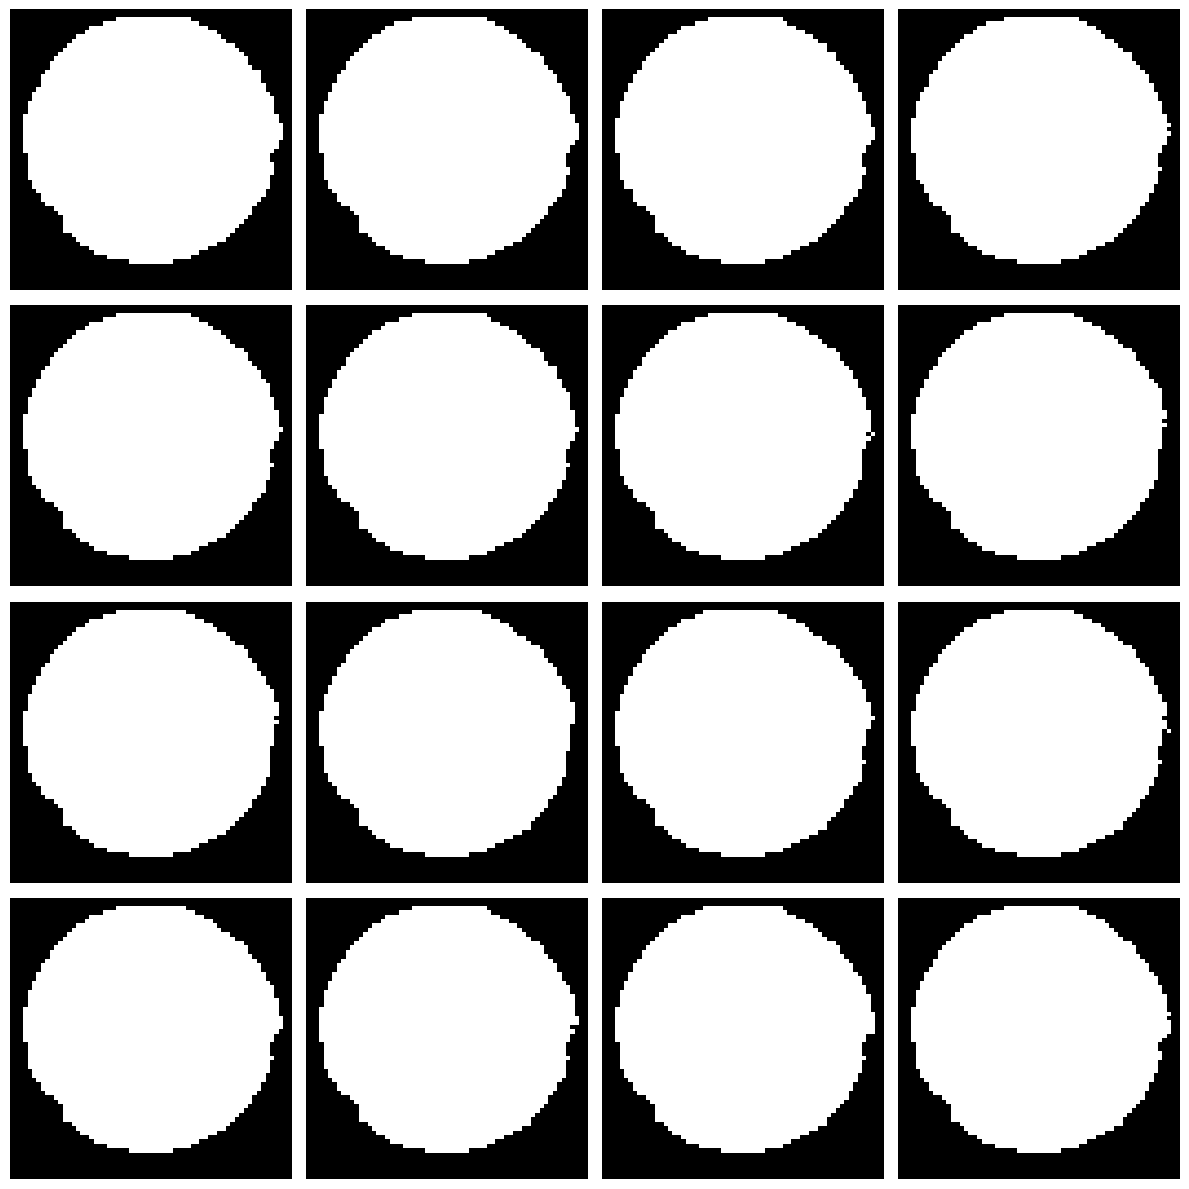

In [ ]:
for idx, (videos, targets) in enumerate(train_loader):
    print(idx)
    print(videos.shape)
    show(videos[1].data.cpu())
    break

## Model

In [ ]:
torch.cuda.empty_cache()

N_VALUES_CLOUD_MASK = 5

hidden_dims = [128, 128, 64]
kernel_size = (3, 3)
n_layers = 3
clstm = ConvLSTMmodels.SegmentedConvLSTMNet(hidden_dims, kernel_size, n_layers, device, n_channels=N_VALUES_CLOUD_MASK, batch_normalization=False)
lr = 1e-3

last_epoch = 0
if os.path.exists(output_path):
    clstm.load_state_dict(torch.load(output_path, map_location='cpu'))
    last_epoch = 50
    lr = 1e-4
else:
    print('No states loaded')

No states loaded


In [ ]:
#print(clstm)

In [ ]:
from importlib import reload
import ConvLSTMmodels
reload(ConvLSTMmodels)

<module 'ConvLSTMmodels' from '/content/gdrive/MyDrive/Universidad/VIU/TFM/notebooks/ConvLSTM/ConvLSTMmodels.py'>

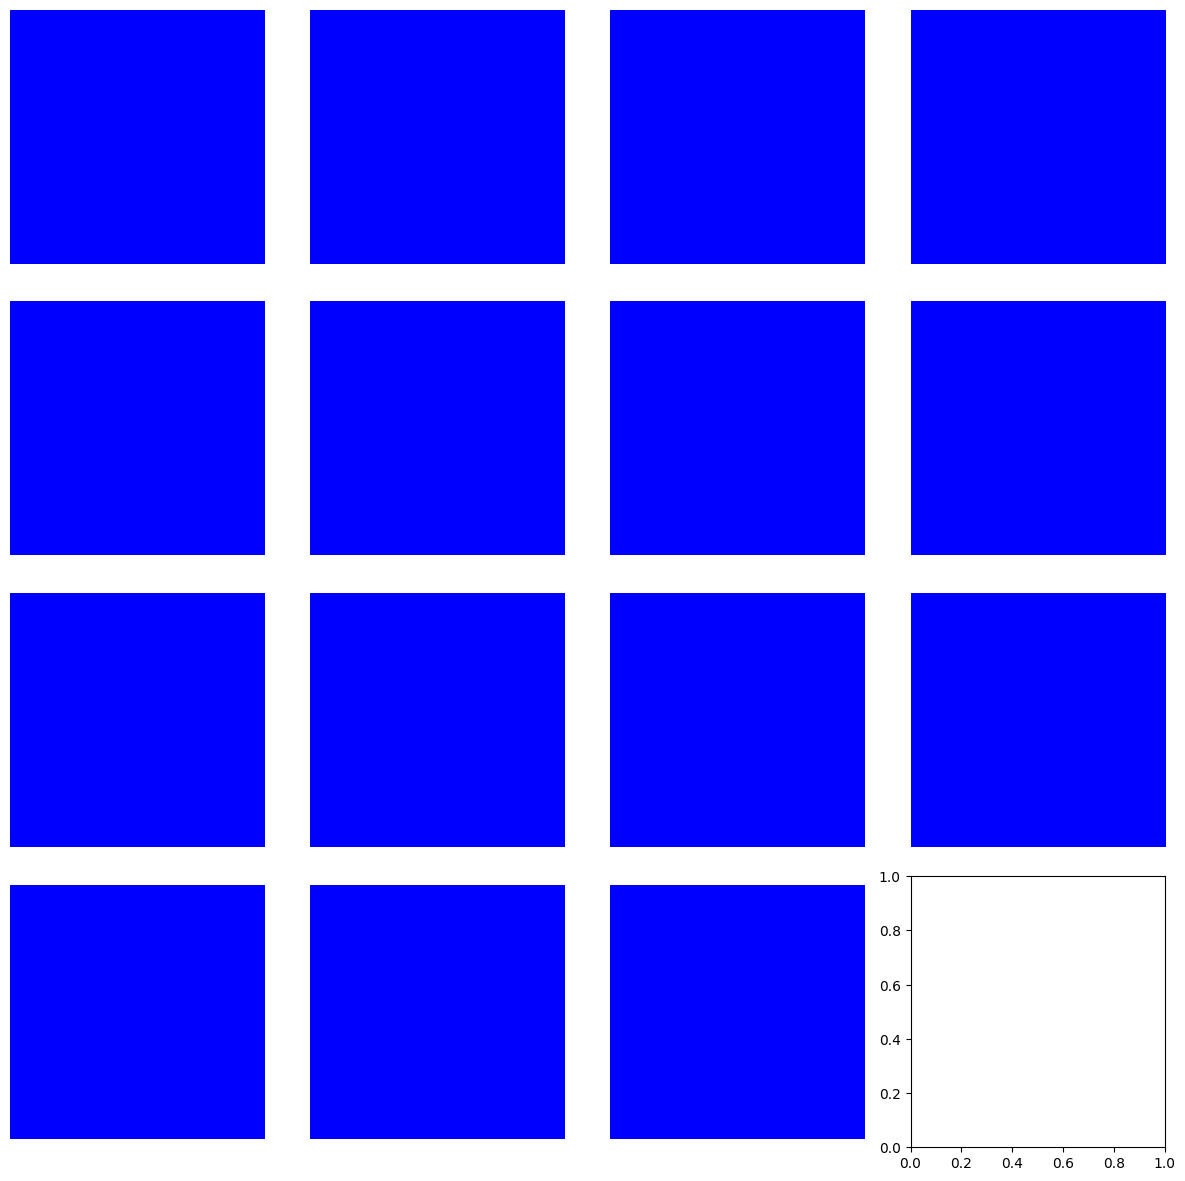

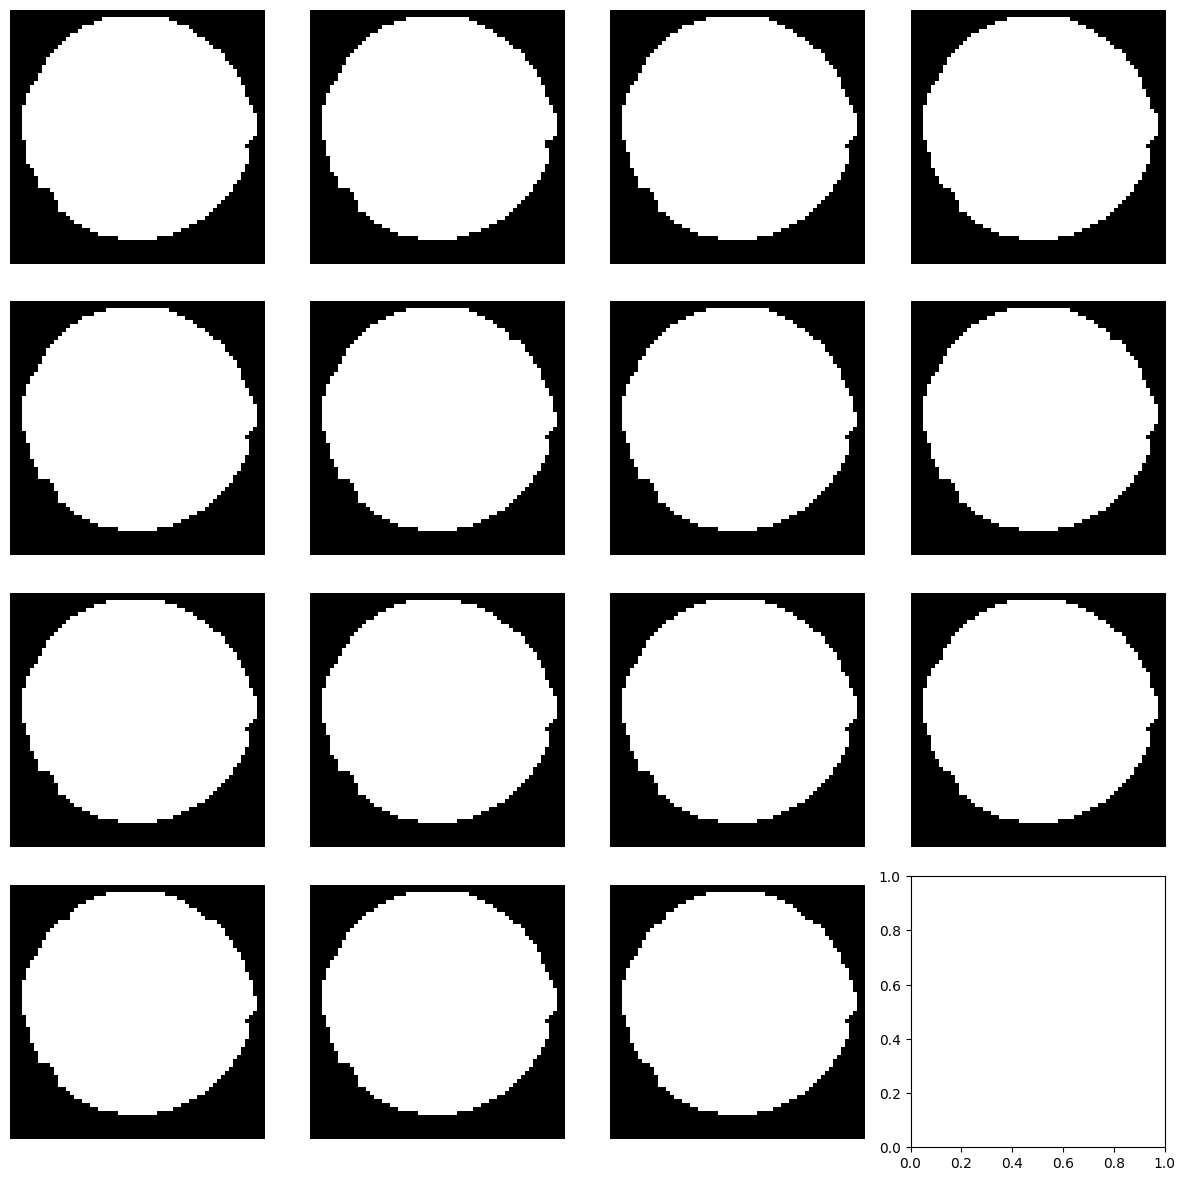

In [ ]:
with torch.no_grad():
    input_video, target_video = train_dataset[randint(1, 5000)]
    pred = clstm(input_video.unsqueeze(0), 15).squeeze(0)
    show(pred.data.cpu())
    show(target_video.data.cpu())

## Training

### Loss function

In [ ]:
def compute_class_counts_from_loader(train_loader, device, num_classes, max_batches=None):
    counts = torch.zeros(num_classes, dtype=torch.float64, device=device)
    n = 0
    for i, (videos, targets) in enumerate(train_loader):
        videos = videos.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        # targets: [B,T,C,H,W] one-hot
        targets = targets.to(device, non_blocking=True)
        # suma por píxel y tiempo (conteo de "unos" por clase)
        counts += targets.sum(dim=(0, 1, 3, 4)).double()
        if n % 20 == 0:
            print(f"Processed {n}/{len(train_loader)}")
        n += 1
        if max_batches is not None and n >= max_batches:
            break
    return counts

In [ ]:
#counts = compute_class_counts_from_loader(train_loader, device, N_VALUES_CLOUD_MASK, max_batches=None)
counts = torch.tensor(
    [1.0962e+09, 6.8944e+08, 1.1347e+07, 1.0283e+09, 1.2405e+08],
    dtype=torch.float64,
    device=device   # o 'cpu' si prefieres
)
print("counts:", counts.detach().cpu())

counts: tensor([1.0962e+09, 6.8944e+08, 1.1347e+07, 1.0283e+09, 1.2405e+08],
       dtype=torch.float64)


In [ ]:
def weights_effective_number(counts: torch.Tensor, beta: float = 0.9999, w_max: float = 10.0):
    # Cui et al.: (1-beta)/(1-beta^n)
    n = counts.float().clamp(min=1.0)
    w = (1.0 - beta) / (1.0 - torch.pow(beta, n))
    w = w / w.mean()
    return torch.clamp(w, max=w_max)

In [ ]:
def class_weights_median_freq(counts: torch.Tensor, eps: float = 1e-12,
                              w_min: float = 0.5, w_max: float = 10.0):
    freq = counts / counts.sum()
    med = torch.median(freq)
    w = med / (freq + eps)
    w = w / w.mean()                 # mantiene escala estable
    w = torch.clamp(w, min=w_min, max=w_max)    # cap anti-dominación
    w = w / w.mean()                 # re-normaliza tras cap (opcional pero recomendable)
    return w.float()

In [ ]:
def class_weights_power_from_counts(counts, alpha=0.75, eps=1e-12, w_min=0.10, w_max=10.0):
    freq = counts / counts.sum()
    w = (1.0 / (freq + eps)) ** alpha
    w = w / w.mean()
    w = torch.clamp(w, min=w_min, max=w_max)
    w = w / w.mean()
    return w.float()


In [ ]:
def class_weights_enet_log(counts, k=1.02, eps=1e-12, w_min=0.10, w_max=5.0):
    """
    ENet-style: w_c = 1 / log(k + p_c)
    p_c: pixel frequency
    k: >1 (1.02 es típico; sube k => menos agresivo)
    """
    p = counts / counts.sum()
    w = 1.0 / torch.log(torch.tensor(k, device=counts.device) + p + eps)
    w = w / w.mean()
    w = torch.clamp(w, min=w_min, max=w_max)
    w = w / w.mean()
    return w.float()

In [ ]:
class_weights = weights_effective_number(counts, beta=0.9999999, w_max=10.0).float()
print("class_weights:", class_weights.detach().cpu())
class_weights = class_weights_median_freq(counts, w_min=0.15, w_max=10.0).to(device)
print("class_weights:", class_weights.detach().cpu())
class_weights = class_weights_power_from_counts(counts, w_min=0.1, w_max=10.0).to(device)
print("class_weights:", class_weights.detach().cpu())
class_weights = class_weights_enet_log(counts, k=1.02, w_min=0.10, w_max=5.0).to(device)
print("class_weights:", class_weights.detach().cpu())
class_weights = torch.tensor(
    [0.2171, 0.3173, 3.0450, 0.2287, 1.1918],
    dtype=torch.float32,
    device=device
)

class_weights: tensor([0.9348, 0.9348, 1.2608, 0.9348, 0.9348])
class_weights: tensor([0.1420, 0.1420, 4.1907, 0.1420, 0.3833])
class_weights: tensor([0.1269, 0.1797, 3.9100, 0.1331, 0.6503])
class_weights: tensor([0.2171, 0.3173, 3.0450, 0.2287, 1.1919])


In [ ]:
class_names = ["other" , "cloud_free", "sun", "cloud", "thin_cloud"]  # ajusta esto a TU orden real

freq = (counts / counts.sum()).detach().cpu().numpy()
w = class_weights.detach().cpu().numpy()

for i, name in enumerate(class_names):
    print(i, name, "freq=", freq[i], "w=", w[i])

0 other freq= 0.371676753114344 w= 0.2171
1 cloud_free freq= 0.23376101137306451 w= 0.3173
2 sun freq= 0.003847305343539921 w= 3.045
3 cloud freq= 0.34865462983714646 w= 0.2287
4 thin_cloud freq= 0.0420603003319051 w= 1.1918


### Training

In [ ]:
torch.cuda.empty_cache()
loss_function = nn.CrossEntropyLoss(weight=class_weights, reduction='mean')
optimizer = torch.optim.Adam(clstm.parameters(), lr=lr)
epochs = 50

scheduler_enc = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.3)
eval_every = 1 #3 #5

epoch_losses = []
epoch_test_losses = []
epoch_lrs = []

best_val_loss = float("inf")
best_epoch = -1
best_model_path = output_path.replace(".torch", "_best.torch")

clstm.train()

for epoch in range(last_epoch, epochs):
  torch.cuda.empty_cache()
  teacher_forcing_ratio = np.maximum(0 , 1 - epoch * 0.03)
  print(f"Epoch[{epoch+1}/{epochs}] teacher_forcing_ratio: {teacher_forcing_ratio}")
  epoch_loss = 0
  n_batches = 0
  for idx, (videos, targets) in enumerate(train_loader):
    #clstm.zero_grad()
    videos = videos.to(device, non_blocking=True)
    targets = targets.to(device, non_blocking=True)

    outputs = clstm(videos, targets.size(1), targets, teacher_forcing_ratio, True, apply_softmax=False)
    targets = torch.cat([videos[:, 1:], targets], dim=1)  # (B, T_total, C, H, W)
    targets_idx = targets.argmax(dim=2)  # (B, T_total, H, W)

    B, T, C, H, W = outputs.shape
    outputs_flat = outputs.view(B*T, C, H, W)
    targets_flat = targets_idx.view(B*T, H, W)

    loss = loss_function(outputs_flat, targets_flat)

    outputs = None
    optimizer.zero_grad()
    loss.backward()
    # If clip gradient to avoid exploding gradient:
    #torch.nn.utils.clip_grad_norm_(clstm.parameters(), max_norm=1.0)
    optimizer.step()
    n_batches += 1
    if idx % 20 == 0:
      to_print = (
          f"Epoch[{epoch+1}/{epochs}] B[{idx+1}/{len(train_loader)}]"
          f" Loss: {loss.item():.4g} "
      )
      print(to_print)
    epoch_loss += loss.item()
  avg_train_loss = epoch_loss / max(n_batches, 1)
  print(f"[TRAIN] Epoch {epoch+1} - Avg Loss: {avg_train_loss:.4g}")
  torch.save(clstm.state_dict(), output_path)
  epoch_losses.append(avg_train_loss)
  if (epoch+1) % eval_every == 0:
    with torch.no_grad():
      loss = 0
      n_batches = 0
      clstm.eval()
      for idx, (videos, targets) in enumerate(val_loader):
        videos = videos.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        outputs = clstm(videos, targets.size(1), None, 0, True, False)
        targets_full = torch.cat([videos[:, 1:], targets], dim=1)
        targets_idx = targets_full.argmax(dim=2)
        B, T, C, H, W = outputs.shape
        outputs_flat = outputs.view(B * T, C, H, W)
        targets_flat = targets_idx.view(B * T, H, W)
        lossp = loss_function(outputs_flat, targets_flat)
        loss += lossp.item()
        n_batches += 1
        lossp = None
        outputs = None
      avg_loss = loss / max(n_batches, 1)
      scheduler_enc.step(avg_loss)
      print(f"[EVAL] Epoch {epoch+1} - Loss: {avg_loss:.4g}")
      print(f"Last learning rate: {scheduler_enc.get_last_lr()}")
      epoch_lrs.append(scheduler_enc.get_last_lr())
      epoch_test_losses.append(avg_loss)
      if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        best_epoch = epoch + 1
        torch.save(clstm.state_dict(), best_model_path)
        print(
            f"--> New best model at epoch {best_epoch} "
            f"(val loss {best_val_loss:.4g}) saved to {best_model_path}"
        )
    clstm.train()
  print("All train losses:", epoch_losses)
  print("All eval losses:", epoch_test_losses)

Streaming output truncated to the last 5000 lines.
Epoch[4/50] B[1061/2001] Loss: 0.1521 
Epoch[4/50] B[1081/2001] Loss: 0.1386 
Epoch[4/50] B[1101/2001] Loss: 0.1165 
Epoch[4/50] B[1121/2001] Loss: 0.1685 
Epoch[4/50] B[1141/2001] Loss: 0.1877 
Epoch[4/50] B[1161/2001] Loss: 0.147 
Epoch[4/50] B[1181/2001] Loss: 0.1614 
Epoch[4/50] B[1201/2001] Loss: 0.1557 
Epoch[4/50] B[1221/2001] Loss: 0.1228 
Epoch[4/50] B[1241/2001] Loss: 0.1282 
Epoch[4/50] B[1261/2001] Loss: 0.1519 
Epoch[4/50] B[1281/2001] Loss: 0.1575 
Epoch[4/50] B[1301/2001] Loss: 0.176 
Epoch[4/50] B[1321/2001] Loss: 0.1173 
Epoch[4/50] B[1341/2001] Loss: 0.1798 
Epoch[4/50] B[1361/2001] Loss: 0.1406 
Epoch[4/50] B[1381/2001] Loss: 0.1288 
Epoch[4/50] B[1401/2001] Loss: 0.1209 
Epoch[4/50] B[1421/2001] Loss: 0.1743 
Epoch[4/50] B[1441/2001] Loss: 0.1302 
Epoch[4/50] B[1461/2001] Loss: 0.1395 
Epoch[4/50] B[1481/2001] Loss: 0.132 
Epoch[4/50] B[1501/2001] Loss: 0.1414 
Epoch[4/50] B[1521/2001] Loss: 0.1663 
Epoch[4/50] B[15

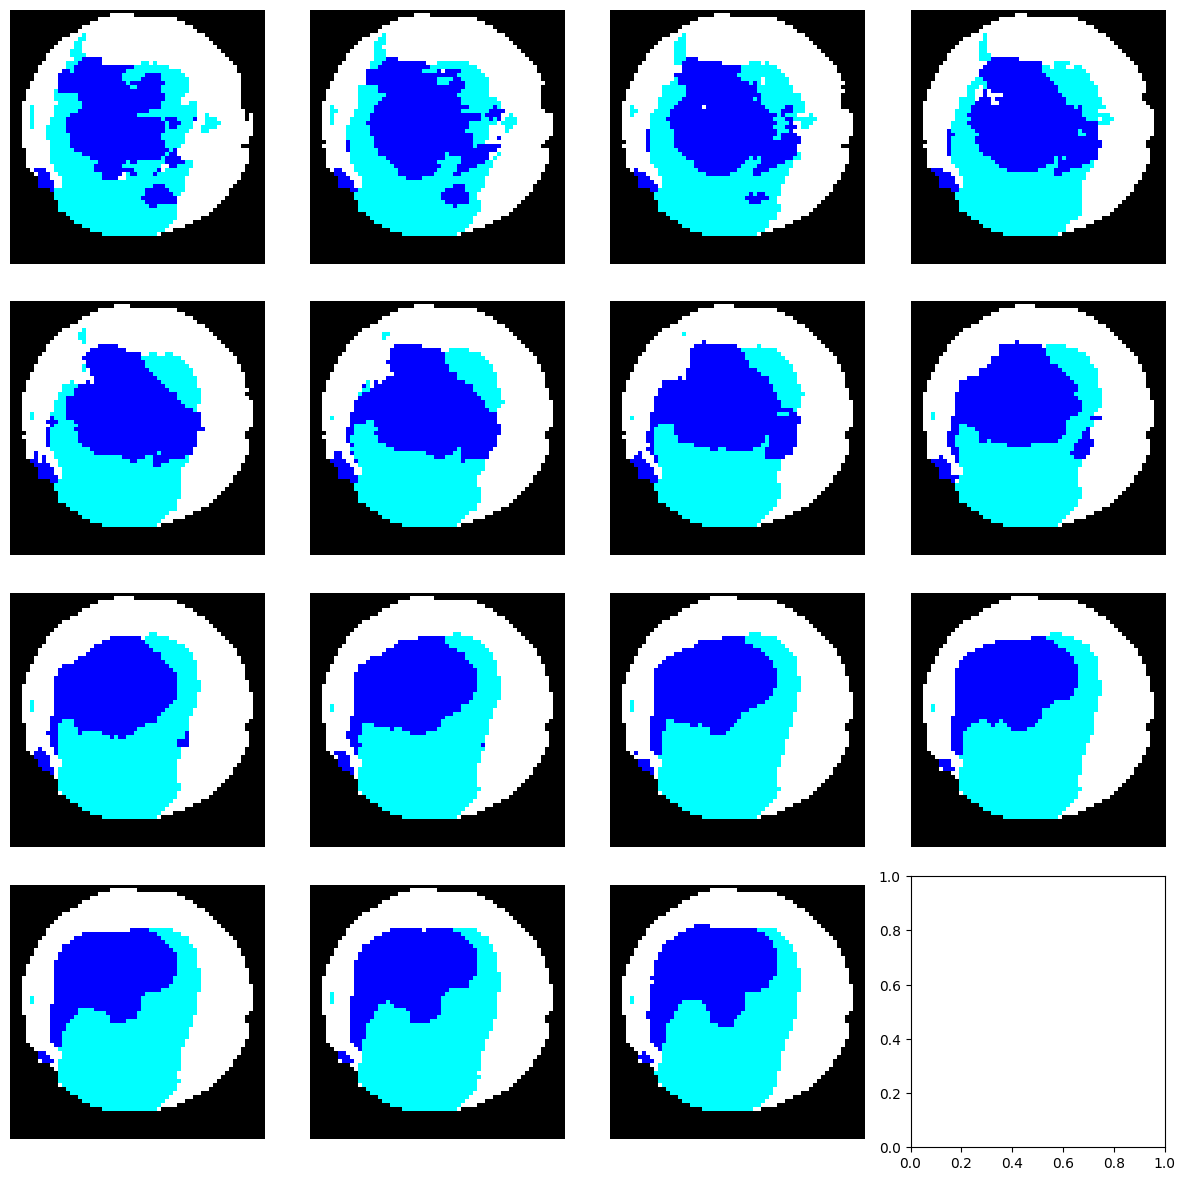

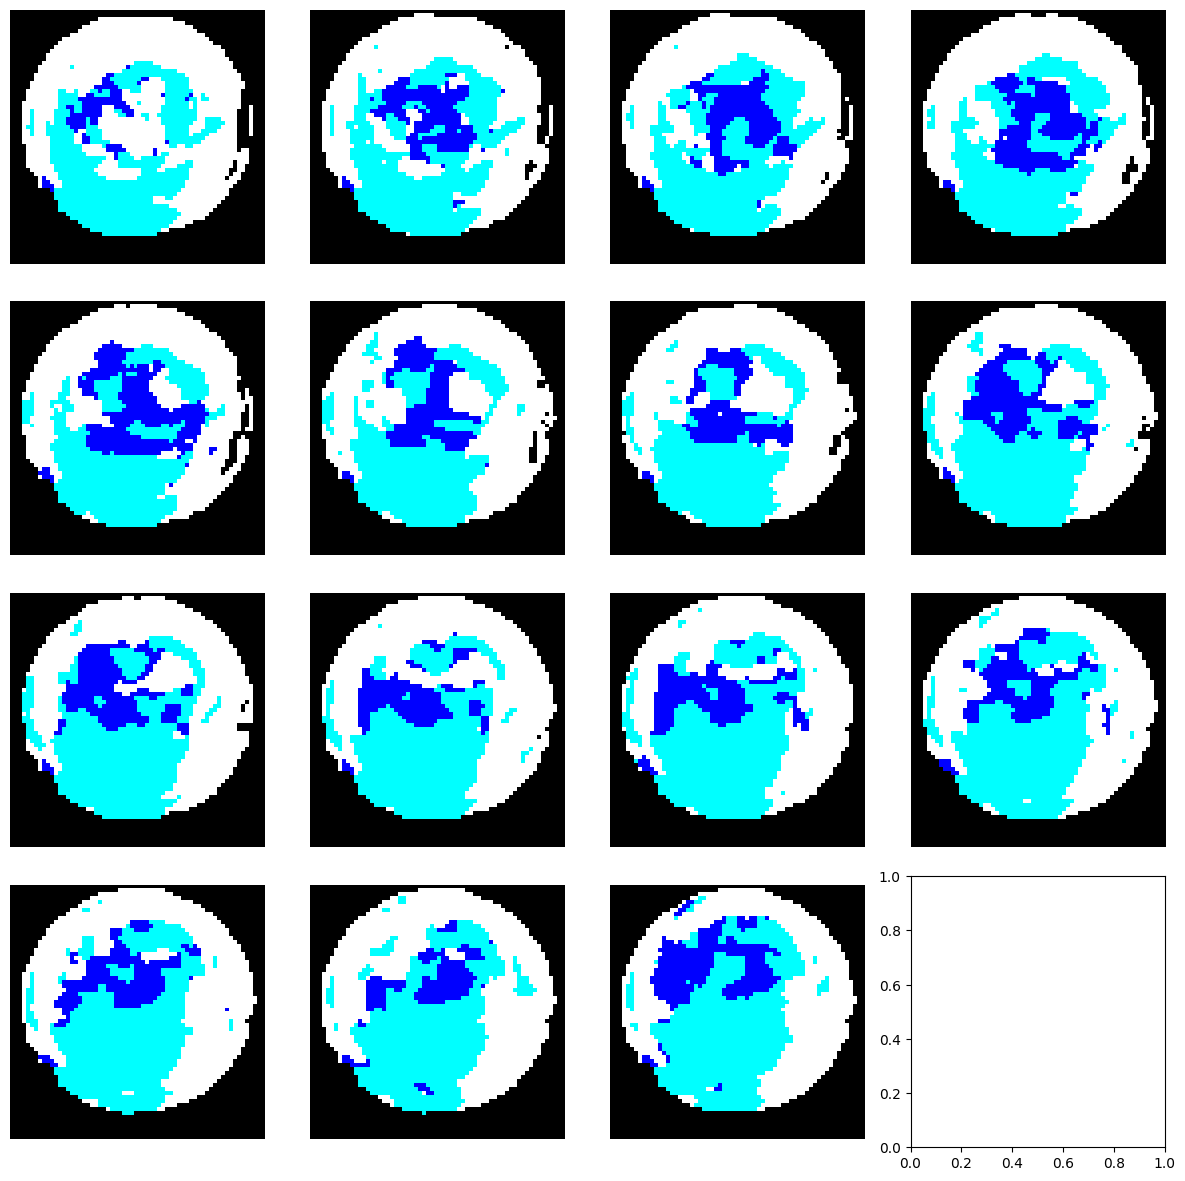

In [ ]:
with torch.no_grad():
    input_video, target_video = train_dataset[randint(1, 5000)]
    pred = clstm(input_video.unsqueeze(0), 15).squeeze(0)
    show(pred.data.cpu())
    show(target_video.data.cpu())

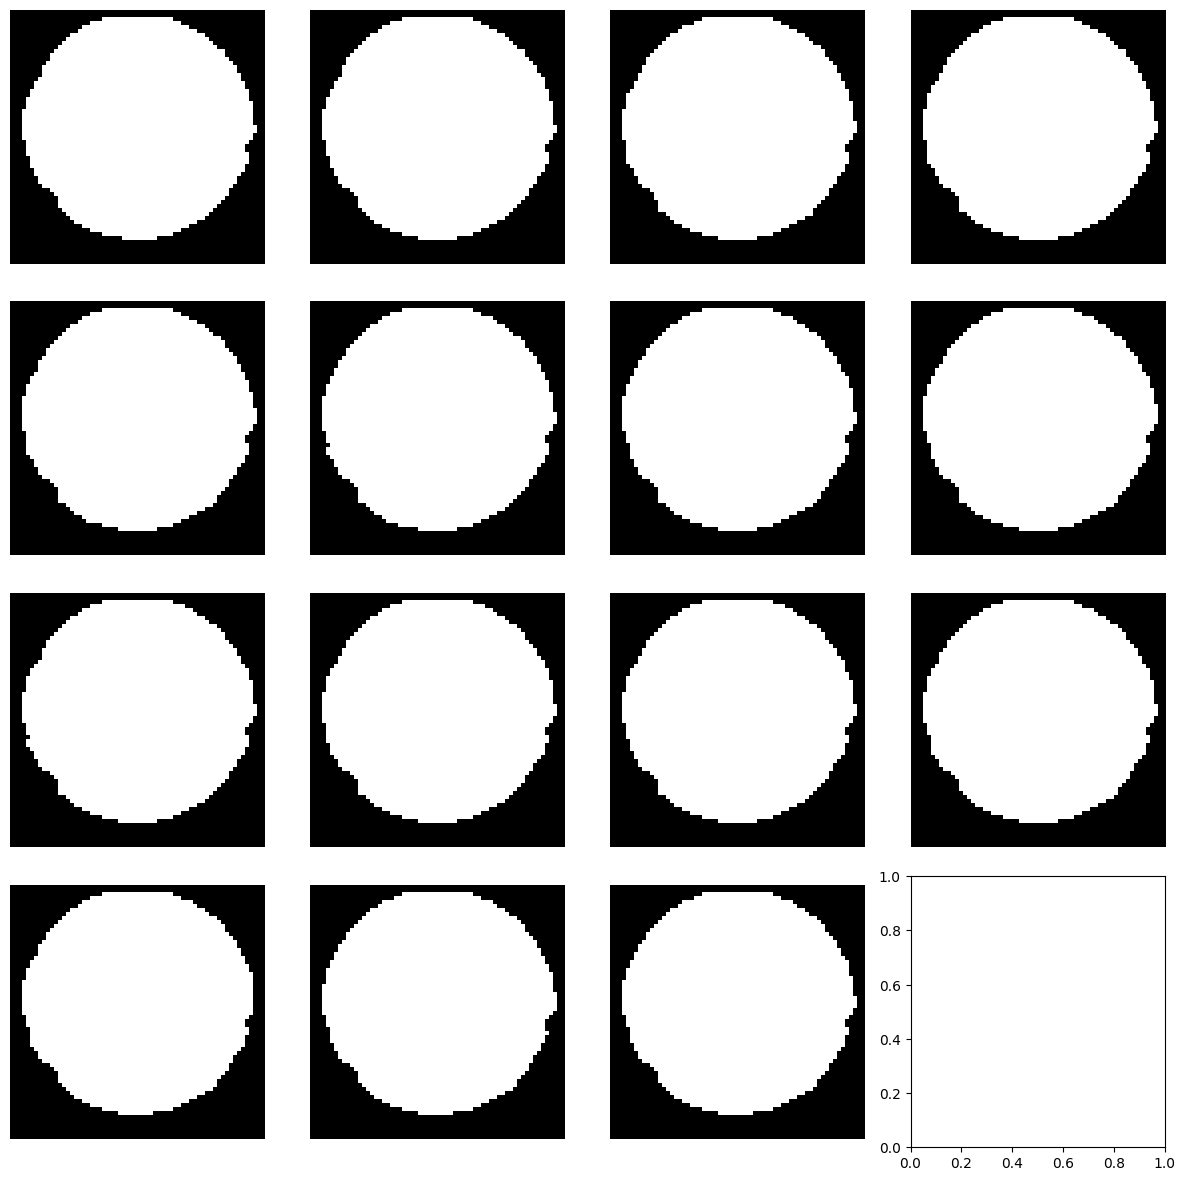

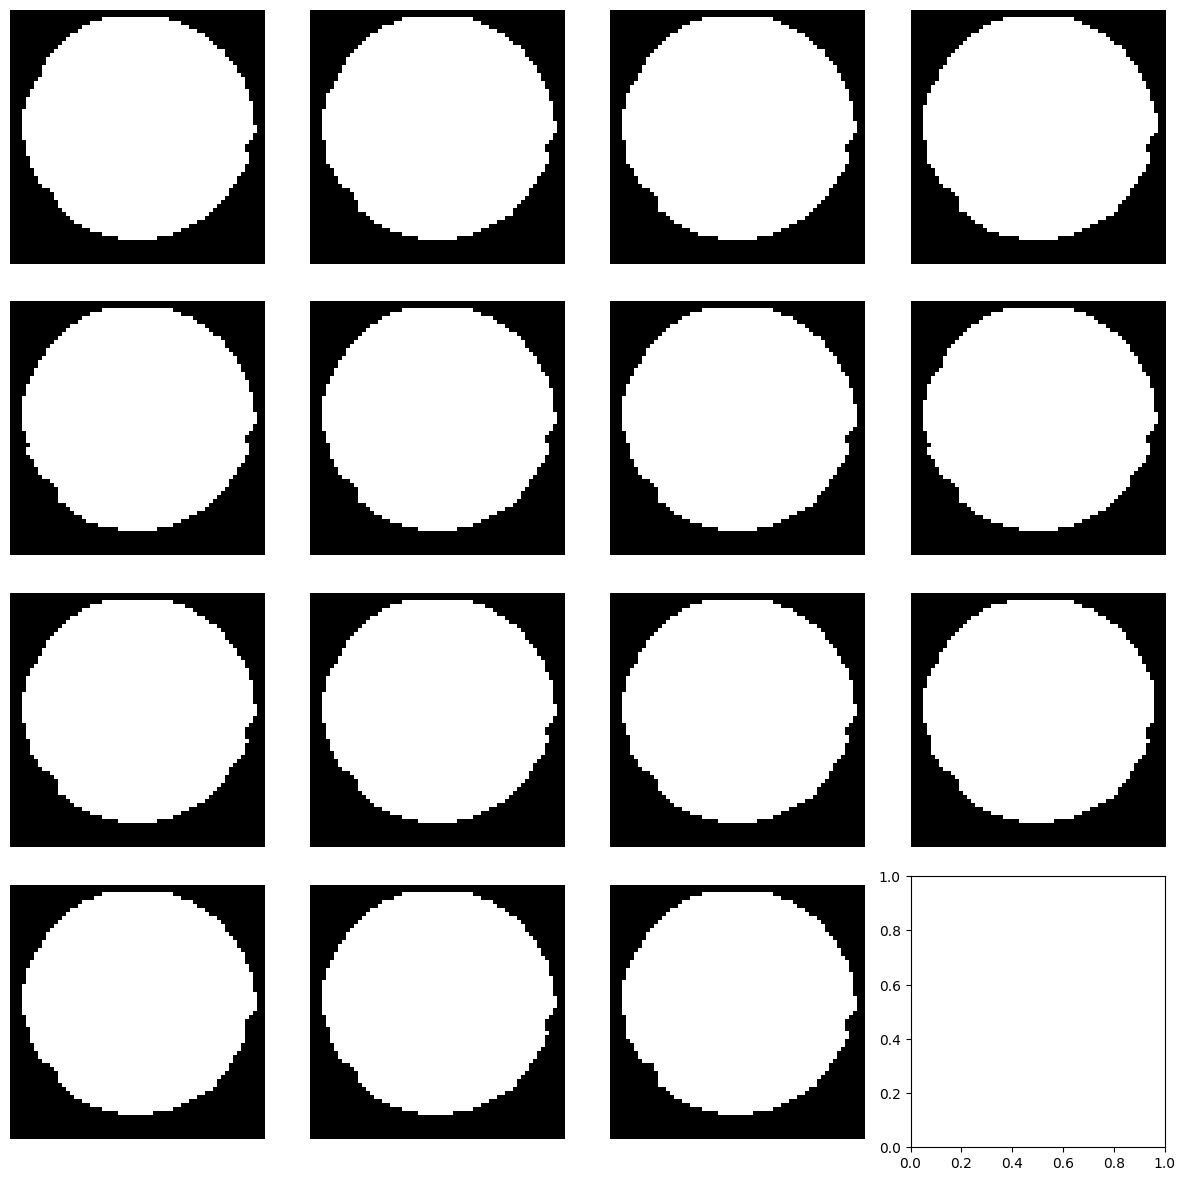

In [ ]:
# Predict with always given the true target value for previous calcs
with torch.no_grad():
    input_video, target_video = train_dataset[randint(1, 5000)]
    pred = clstm(input_video.unsqueeze(0), 15, target_video.unsqueeze(0), 1).squeeze(0)
    show(pred.data.cpu())
    show(target_video.data.cpu())

In [ ]:
with torch.no_grad():
  for i in range(0, 2000, 10):
    input_video, target_video = test_dataset[i]
    pred = clstm(input_video.unsqueeze(0), 15).squeeze(0)
    print(i)
    show(pred.data.cpu())
    show(target_video.data.cpu())